# Import Libraries


In [ ]:
import os
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import urllib.request
import zipfile
import tarfile

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import hinge_loss


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# Download and Extract the Dataset

In [ ]:
!wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

!tar -xvzf aclImdb_v1.tar.gz

Streaming output truncated to the last 5000 lines.
aclImdb/train/unsup/44983_0.txt
aclImdb/train/unsup/44982_0.txt
aclImdb/train/unsup/44981_0.txt
aclImdb/train/unsup/44980_0.txt
aclImdb/train/unsup/44979_0.txt
aclImdb/train/unsup/44978_0.txt
aclImdb/train/unsup/44977_0.txt
aclImdb/train/unsup/44976_0.txt
aclImdb/train/unsup/44975_0.txt
aclImdb/train/unsup/44974_0.txt
aclImdb/train/unsup/44973_0.txt
aclImdb/train/unsup/44972_0.txt
aclImdb/train/unsup/44971_0.txt
aclImdb/train/unsup/44970_0.txt
aclImdb/train/unsup/44969_0.txt
aclImdb/train/unsup/44968_0.txt
aclImdb/train/unsup/44967_0.txt
aclImdb/train/unsup/44966_0.txt
aclImdb/train/unsup/44965_0.txt
aclImdb/train/unsup/44964_0.txt
aclImdb/train/unsup/44963_0.txt
aclImdb/train/unsup/44962_0.txt
aclImdb/train/unsup/44961_0.txt
aclImdb/train/unsup/44960_0.txt
aclImdb/train/unsup/44959_0.txt
aclImdb/train/unsup/44958_0.txt
aclImdb/train/unsup/44957_0.txt
aclImdb/train/unsup/44956_0.txt
aclImdb/train/unsup/44955_0.txt
aclImdb/train/unsup/4

# Load Training and Test Dataset into Dataframe

In [ ]:
def load_reviews(directory, label):

    reviews = []

    for filename in os.listdir(directory):

        file_path = os.path.join(directory, filename)

        with open(file_path, 'r', encoding='utf-8') as file:

            review = file.read()

            reviews.append([review, label])

    return reviews




In [ ]:
positive_reviews = load_reviews('/content/aclImdb/train/pos', 1)
negative_reviews = load_reviews('/content/aclImdb/train/neg', 0)

train_data = positive_reviews + negative_reviews

df_train = pd.DataFrame(train_data, columns=['review', 'sentiment'])
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
positive_reviews = load_reviews('/content/aclImdb/test/pos', 1)
negative_reviews = load_reviews('/content/aclImdb/test/neg', 0)

test_data = positive_reviews + negative_reviews

df_test= pd.DataFrame(test_data, columns=['review', 'sentiment'])
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)


# Text Preprocessing


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
  text = text.lower()     #to lowercase
  text = re.sub(r'<.*?>', '', text)      #removes html tags
  text = re.sub(r'[^a-zA-Z]', ' ', text)     #removes non-letters
  words = text.split()        # tokenization
  words =[lemmatizer.lemmatize(word) for word in words if word not in stop_words]

  return ' '.join(words)



### Applying the preprocessing steps on both the training and test datasets

In [ ]:
df_train['clean_review'] = df_train['review'].apply(clean_text)

df_test['clean_review'] = df_test['review'].apply(clean_text)

# Converting Text to Numbers
###(TF-IDF Vectorization)

In [ ]:
vectorizer = TfidfVectorizer(max_features=25000,
                             ngram_range=(1,3))

x_train = vectorizer.fit_transform(df_train['clean_review'])
y_train = df_train['sentiment']

x_test = vectorizer.transform(df_test['clean_review'])
y_test = df_test['sentiment']

print(x_train.shape)
print(y_test.shape)

(25000, 25000)
(25000,)


# Train Linear SVM Model

In [ ]:
svm_model = LinearSVC(C=1)

svm_model.fit(x_train, y_train)

print("SVM model trained successfully")

SVM model trained successfully


# Model Evaluation
Model evaluation on the IMDb test set

In [ ]:
y_pred = svm_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.87544


# Classification Report and confusion Matrix
(IMDb test set)

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     12500
           1       0.88      0.86      0.87     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


Confusion Matrix:

[[11076  1424]
 [ 1690 10810]]


# Confusion matrix Visualization
(IMDb test set)

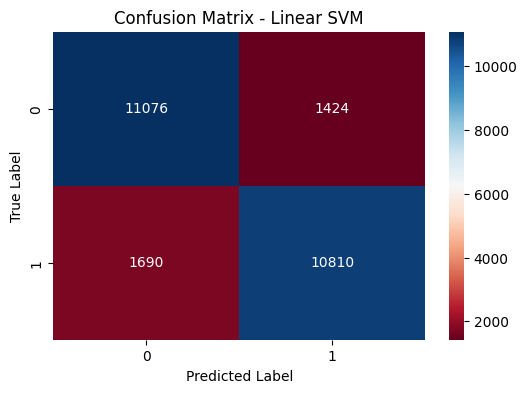

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu')

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ROC Curve

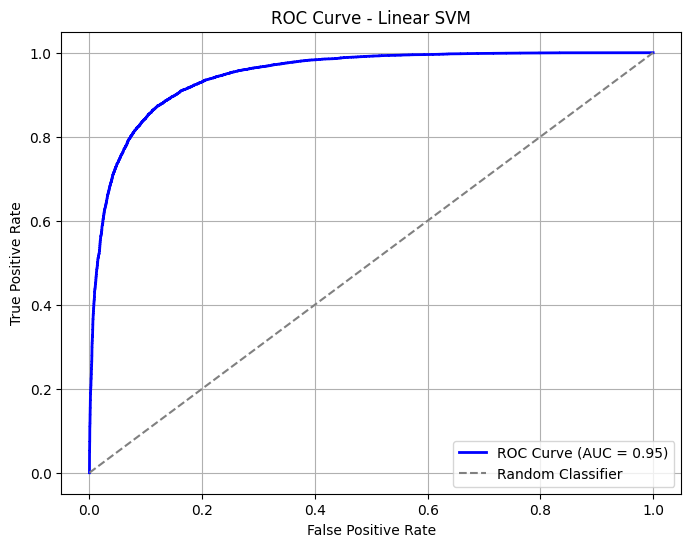

AUC Score: 0.9478


In [ ]:
y_scores = svm_model.decision_function(x_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Linear SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")


# Hinge Loss Function

In [ ]:
y_scores = svm_model.decision_function(x_test)

h_loss = hinge_loss(y_test, y_scores)
print(f"Hinge Loss: {h_loss:.4f}")

Hinge Loss: 0.3779


# Deploying the model on new reviews

In [ ]:
def predict_sentiment(review):
  cleaned = clean_text(review)
  vectorized = vectorizer.transform([cleaned])
  prediction = svm_model.predict(vectorized)[0]

  if prediction == 1:
    return "Positive Review"
  else:
    return "Negative Review"


print(predict_sentiment("This movie was absolutely amazing. I loved every part of it!"))
print(predict_sentiment("The movie was boring and too long. I almost fell asleep."))
print(predict_sentiment("Terrible film. Waste of time and money."))
print(predict_sentiment("Great visuals, but the story was dull and unconvincing."))
print(predict_sentiment("Slow beginning, but a truly moving and memorable ending."))

Positive Review
Negative Review
Negative Review
Negative Review
Positive Review


## Deployment On Cornell Movie Review Dataset

In [ ]:
url = "https://www.cs.cornell.edu/people/pabo/movie-review-data/review_polarity.tar.gz"
urllib.request.urlretrieve(url, "cornell_reviews.tar.gz")

with tarfile.open("cornell_reviews.tar.gz", "r:gz") as tar:
    tar.extractall("cornell_reviews")

print("Download and extraction complete.")

/tmp/ipykernel_2284/586554883.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("cornell_reviews")


Download and extraction complete.


In [ ]:
def load_cornell(folder, label):
    reviews = []
    for filename in os.listdir(folder):
        filepath = os.path.join(folder, filename)
        with open(filepath, 'r', encoding='latin-1') as f:
            reviews.append([f.read(), label])
    return reviews

pos_reviews = load_cornell('cornell_reviews/txt_sentoken/pos', 1)
neg_reviews = load_cornell('cornell_reviews/txt_sentoken/neg', 0)

cornell_data = pos_reviews + neg_reviews
df_cornell = pd.DataFrame(cornell_data, columns=['review', 'sentiment'])
df_cornell = df_cornell.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Cornell samples loaded: {len(df_cornell)}")
print(df_cornell['sentiment'].value_counts())

Cornell samples loaded: 2000
sentiment
0    1000
1    1000
Name: count, dtype: int64


##### Applying the preprocessing pipeline and vectorizatiion

In [ ]:
df_cornell['clean_review'] = df_cornell['review'].apply(clean_text)

x_cornell = vectorizer.transform(df_cornell['clean_review'])
y_cornell = df_cornell['sentiment']

y_cornell_pred = svm_model.predict(x_cornell)

cornell_accuracy = accuracy_score(y_cornell, y_cornell_pred)
cm_cornell = confusion_matrix(y_cornell, y_cornell_pred)

print(f"Cornell Accuracy: {cornell_accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_cornell, y_cornell_pred))
print("\nConfusion Matrix:\n")
print(cm_cornell)


Cornell Accuracy: 0.8610

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1000
           1       0.87      0.85      0.86      1000

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000


Confusion Matrix:

[[872 128]
 [150 850]]
